In [13]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

In [14]:
CLEANED_PATH = "../cleaned"
PREPROCESSED_PATH = "../preprocessed_data"
OUTPUT_PATH = "../../outputs"

CAMERA_COMPARE_DATA = "camera_level_ssusa_iucn_comparison.pkl"
CAMERA_FOOTPRINTS = "ssusa_camera_footprints_1km.geojson"

BASE_NLCD_FOLDER = "../../data/nlcd/Annual_NLCD_LndCov_2024_CU_C1V1"
NLCD_FILENAME = "Annual_NLCD_LndCov_2024_CU_C1V1.tif"

BASE_ROADS_FOLDER = "../../data/tiger_roads"
ROADS_FILENAME = "tl_2025_us_primaryroads"

# Projected CRS for area / distance calculations
AEA = "EPSG:5070"



In [78]:
def make_camera_id(lon, lat):
    return f"{lon:.8f}_{lat:.8f}"


# NLCD class groups used in this analysis
FOREST_CLASSES = [41, 42, 43]
GRASS_CLASSES = [71, 72, 73, 74]
WETLAND_CLASSES = [90, 95]
DEVELOPED_CLASSES = [21, 22, 23, 24]
CROP_CLASSES = [81, 82]


pretty_labels = {
    "distance_to_road_m": "Distance to Road (m)",
    "forest_pct": "Forest Cover (%)",
    "grass_pct": "Grassland Cover (%)",
    "wetland_pct": "Wetland Cover (%)",
    "developed_pct": "Developed Land (%)",
    "crop_pct": "Cropland (%)"
}


def extract_nlcd_percent(footprints_gdf, raster_path):
    """
    Extract land-cover percentages inside each camera footprint polygon.

    Returns the input GeoDataFrame with five new columns:
    forest_pct, grass_pct, wetland_pct, developed_pct, crop_pct
    """
    gdf = footprints_gdf.copy()

    out_cols = [
        "forest_pct",
        "grass_pct",
        "wetland_pct",
        "developed_pct",
        "crop_pct",
    ]
    for col in out_cols:
        gdf[col] = np.nan

    with rasterio.open(raster_path) as src:
        # Reproject footprints to raster CRS once before looping
        gdf_raster = gdf.to_crs(src.crs)

        # for each footprint, mask the raster to the polygon and calculate class percentages
        for idx, row in gdf_raster.iterrows():
            geom = [row.geometry]

            try:
                # mask() returns a 3D array (bands, rows, cols) and a transform
                clipped, _ = mask(src, geom, crop=True)

                # Extract the single band and flatten to 1D
                # first band is the land cover class values
                values = clipped[0]
                # Remove nodata values
                values = values[values != src.nodata]

                if len(values) == 0:
                    continue

                total = len(values)

                gdf.loc[idx, "forest_pct"] = np.isin(values, FOREST_CLASSES).sum() / total
                gdf.loc[idx, "grass_pct"] = np.isin(values, GRASS_CLASSES).sum() / total
                gdf.loc[idx, "wetland_pct"] = np.isin(values, WETLAND_CLASSES).sum() / total
                gdf.loc[idx, "developed_pct"] = np.isin(values, DEVELOPED_CLASSES).sum() / total
                gdf.loc[idx, "crop_pct"] = np.isin(values, CROP_CLASSES).sum() / total

            except Exception:
                # Leave percentages as NaN if clipping fails for a footprint
                continue

    return gdf


def fit_and_evaluate_rf(X, y, random_state=42, n_estimators=300):
    """Train/test split, fit RF, and return model, predictions, and metrics."""
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=random_state,
    )

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    return model, X_train, X_test, y_train, y_test, y_pred, r2, rmse


def plot_observed_vs_predicted(y_true, y_pred, title):
    """Scatter plot of observed vs predicted values with 1:1 reference line."""
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.4)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Observed Jaccard Index")
    plt.ylabel("Predicted Jaccard Index")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, title, top_n=None):
    """Horizontal bar plot for RF feature importance."""

    importance = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)

    if top_n is not None:
        importance = importance.head(top_n)

    # Replace technical names with readable labels for plotting only
    plot_importance = importance.copy()
    plot_importance.index = plot_importance.index.to_series().replace(pretty_labels)

    # Colors
    bg_color = "#FDFBF3"
    main_color = "#1F3A5F"
    axis_color = "#706A58"

    # Figure sized to requested dimensions
    fig, ax = plt.subplots(figsize=(10.5, 3.4), facecolor=bg_color)
    ax.set_facecolor(bg_color)

    # Plot
    plot_importance.sort_values().plot(
        kind="barh",
        ax=ax,
        color=main_color
    )

    # Title and labels
    ax.set_title(
        title,
        fontsize=13,
        color=main_color,
        pad=10
    )

    ax.set_xlabel(
        "Feature Importance Score\n"
        "(Contribution to Jaccard Similarity Prediction Accuracy of Random Forest Model)",
        fontsize=10,
        color=axis_color,
        labelpad=8
    )

    ax.set_ylabel("")

    # Tick styling
    ax.tick_params(axis="x", colors=axis_color, labelsize=9)
    ax.tick_params(axis="y", colors=axis_color, labelsize=9)

    # Spine colors
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(axis_color)

    plt.tight_layout()
    plt.show()

    return plot_importance

In [16]:
# Read camera-level comparison data
# --------------------------------------------------
camera_compare = pd.read_pickle(os.path.join(OUTPUT_PATH, CAMERA_COMPARE_DATA))

print("camera_compare shape:", camera_compare.shape)
print(camera_compare.columns.tolist())

camera_compare shape: (7340, 21)
['camera_fp_id', 'Habitat', 'Development_Level', 'Feature_Type', 'Camera_Trap_Array', 'Longitude', 'Latitude', 'unique_nights', 'obs_species', 'S_obs', 'pred_species', 'S_pred', 'overlap_species', 'missing_species', 'additional_species', 'union_species', 'overlap_n', 'missing_n', 'additional_n', 'union_n', 'jaccard_index']


### Create clean RF base table

In [19]:
# Keep rows that can be used in RF modeling
rf_base = camera_compare.dropna(
    subset=["Longitude", "Latitude", "jaccard_index"]
).copy()

# Ensure camera_fp_id exists
if "camera_fp_id" not in rf_base.columns:
    rf_base["camera_fp_id"] = make_camera_id(rf_base["Longitude"], rf_base["Latitude"])

print("rf_base shape:", rf_base.shape)


rf_base shape: (7340, 21)


In [20]:
# Read Camera footprints - already have footprints with camera_fp_id
# --------------------------------------------------
camera_fp = gpd.read_file(os.path.join(PREPROCESSED_PATH, CAMERA_FOOTPRINTS))


print("camera_fp shape:", camera_fp.shape)
print("camera_fp CRS:", camera_fp.crs)
print(camera_fp.columns.tolist())


camera_fp shape: (7340, 4)
camera_fp CRS: EPSG:5070
['Longitude', 'Latitude', 'camera_fp_id', 'geometry']


In [22]:
# --------------------------------------------------
# Check ID overlap between tables
# --------------------------------------------------
missing_fp_ids = set(camera_fp["camera_fp_id"]) - set(rf_base["camera_fp_id"])
missing_rf_ids = set(rf_base["camera_fp_id"]) - set(camera_fp["camera_fp_id"])

print("Footprint IDs not in rf_base:", len(missing_fp_ids))
print("rf_base IDs not in footprints:", len(missing_rf_ids))

Footprint IDs not in rf_base: 0
rf_base IDs not in footprints: 0


### Extract NLCD percentages

In [23]:
nlcd_path = os.path.join(BASE_NLCD_FOLDER, NLCD_FILENAME)

camera_fp_nlcd = extract_nlcd_percent(camera_fp, nlcd_path)

camera_fp_nlcd[
    ["forest_pct", "grass_pct", "wetland_pct", "developed_pct", "crop_pct"]
].describe()

,forest_pct,grass_pct,wetland_pct,developed_pct,crop_pct
count,7263.000000,7263.000000,7263.000000,7263.000000,7263.000000
mean,0.432455,0.067856,0.087831,0.189268,0.091004
std,0.346434,0.188735,0.172219,0.283138,0.174316
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.058537,0.000000,0.000000,0.015506,0.000000
50%,0.422216,0.002006,0.012069,0.048234,0.002869
75%,0.761098,0.022095,0.085583,0.218182,0.097477
max,1.000000,1.000000,1.000000,1.000000,0.952559


In [26]:
# Merge NLCD percentages into RF table
nlcd_cols = [
    "camera_fp_id",
    "forest_pct",
    "grass_pct",
    "wetland_pct",
    "developed_pct",
    "crop_pct",
]

rf_df = rf_base.merge(
    camera_fp_nlcd[nlcd_cols],
    on="camera_fp_id",
    how="left",
)

print("rf_df shape after NLCD merge:", rf_df.shape)
print(
    rf_df[
        ["forest_pct", "grass_pct", "wetland_pct", "developed_pct", "crop_pct"]
    ].isna().sum()
)

rf_df shape after NLCD merge: (7340, 26)
forest_pct       77
grass_pct        77
wetland_pct      77
developed_pct    77
crop_pct         77
dtype: int64


### Read roads data and compute distance to nearest road for camera points

In [28]:
# Read roads data
roads = gpd.read_file(os.path.join(BASE_ROADS_FOLDER, ROADS_FILENAME))

print("roads shape:", roads.shape)
print("roads CRS:", roads.crs)
print(roads.columns.tolist())

roads shape: (17500, 5)
roads CRS: EPSG:4269
['LINEARID', 'FULLNAME', 'RTTYP', 'MTFCC', 'geometry']


In [ ]:
# Build point geometry for each camera using its longitude and latitude
# -------------------------------------------------------------------
# We use camera POINT locations here instead of the 1-km buffer polygons
# because distance to road should represent how far the actual camera is
# from the nearest road, not how far the surrounding footprint is.
#
# geometry = shapely Point(Longitude, Latitude)
# crs="EPSG:4326" means coordinates are in geographic latitude/longitude
# -------------------------------------------------------------------
camera_pts = gpd.GeoDataFrame(
    rf_base.copy(),
    geometry=gpd.points_from_xy(
        rf_base["Longitude"],
        rf_base["Latitude"]
    ),
    crs="EPSG:4326"
)

# Reproject both cameras and roads into a projected CRS
# -------------------------------------------------------------------
# Distance calculations should NOT be done in latitude/longitude degrees.
# They should be done in a projected CRS with linear units such as meters.
#
# EPSG:5070 = NAD83 / Conus Albers
# This is commonly used for U.S.-wide spatial analysis.
# -------------------------------------------------------------------
camera_pts_aea = camera_pts.to_crs(AEA)
roads_aea = roads.to_crs(AEA)

# -------------------------------------------------------------------
# Combine all road segments into one geometry
# -------------------------------------------------------------------
# roads_aea contains many separate line features.
# union_all() merges them into a single multilinestring-like geometry.
#
# That makes it easy to compute distance from each camera point
# to the nearest road anywhere in the roads dataset.
# -------------------------------------------------------------------
roads_union = roads_aea.geometry.union_all()

# -------------------------------------------------------------------
# Compute distance from each camera point to the nearest road
# -------------------------------------------------------------------
# geometry.distance(roads_union) returns the shortest distance
# from each camera point to the merged road network geometry.
#
# Because we are now in EPSG:5070, the distance is in METERS.
# -------------------------------------------------------------------
camera_pts_aea["distance_to_road_m"] = camera_pts_aea.geometry.distance(roads_union)




KeyError: "['coord_id'] not in index"

In [30]:
# Preview result
camera_pts_aea[["camera_fp_id", "distance_to_road_m"]].head()

,camera_fp_id,distance_to_road_m
0,-100.23311000_35.92725000,77879.977373
1,-100.24179000_35.92768000,77923.075961
2,-100.24180200_35.92767900,77922.961777
3,-100.24181000_35.92775000,77930.910661
4,-100.24212710_35.92756100,77909.694394


In [31]:
# Quick summary of the road-distance variable
# -------------------------------------------------------------------
# This helps check:
# - minimum and maximum distance
# - median distance
# - whether values look reasonable
# - whether there may be outliers
# -------------------------------------------------------------------
print(camera_pts_aea["distance_to_road_m"].describe())

count      7340.000000
mean      32035.494303
std       66028.792193
min          12.917188
25%        3628.030571
50%       12443.669794
75%       35184.854409
max      848420.154015
Name: distance_to_road_m, dtype: float64


In [37]:
# Merge road distance into the RF modeling table
# rf_df already contains:
# - camera-level comparison data
# - NLCD percentages
#
# Now we add one more predictor:
# - distance_to_road_m
#
# We merge by coord_id so each camera gets the correct distance value.
# -------------------------------------------------------------------
rf_df = rf_df.merge(
    camera_pts_aea[["camera_fp_id", "distance_to_road_m"]],
    on="camera_fp_id",
    how="left"
)

# -------------------------------------------------------------------
# Check result after merge
# -------------------------------------------------------------------
print("rf_df shape after road-distance merge:", rf_df.shape)


rf_df shape after road-distance merge: (7340, 29)


In [39]:
print("Missing road distances:", rf_df["distance_to_road_m"].isna().sum())

Missing road distances: 0


In [40]:
# Summarize all environment predictors together
# -------------------------------------------------------------------
# These include:
# - NLCD land-cover proportions
# - distance to nearest road
#
# This helps verify that:
# - values are present
# - percentages are in expected ranges
# - road distance values look plausible
# -------------------------------------------------------------------
rf_df[
    [
        "forest_pct",
        "grass_pct",
        "wetland_pct",
        "developed_pct",
        "crop_pct",
        "distance_to_road_m",
    ]
].describe()

,forest_pct,grass_pct,wetland_pct,developed_pct,crop_pct,distance_to_road_m
count,7263.000000,7263.000000,7263.000000,7263.000000,7263.000000,7340.000000
mean,0.432455,0.067856,0.087831,0.189268,0.091004,32035.494303
std,0.346434,0.188735,0.172219,0.283138,0.174316,66028.792193
min,0.000000,0.000000,0.000000,0.000000,0.000000,12.917188
25%,0.058537,0.000000,0.000000,0.015506,0.000000,3628.030571
50%,0.422216,0.002006,0.012069,0.048234,0.002869,12443.669794
75%,0.761098,0.022095,0.085583,0.218182,0.097477,35184.854409
max,1.000000,1.000000,1.000000,1.000000,0.952559,848420.154015


### Environment-only RF Model Train and Test

In [41]:
# Select environmental predictor columns
# -------------------------------------------------------------------
# These are the geospatially derived variables used in the
# environment-only random forest model.
# -------------------------------------------------------------------
env_features = [
    "forest_pct",
    "grass_pct",
    "wetland_pct",
    "developed_pct",
    "crop_pct",
    "distance_to_road_m",
]

# -------------------------------------------------------------------
# Keep only rows with complete predictor and response data
# -------------------------------------------------------------------
# We must remove rows where any predictor or the response variable
# (jaccard_index) is missing, because RandomForestRegressor cannot
# train directly on NaN values.
# -------------------------------------------------------------------
rf_env = rf_df.dropna(subset=env_features + ["jaccard_index"]).copy()

# -------------------------------------------------------------------
# Build X (predictors) and y (response)
# -------------------------------------------------------------------
# X_env = independent variables
# y_env = dependent variable / outcome to predict
# -------------------------------------------------------------------
X_env = rf_env[env_features]
y_env = rf_env["jaccard_index"]

print("Rows used in environment-only RF:", len(rf_env))
print("Predictor matrix shape:", X_env.shape)
print("Response vector shape:", y_env.shape)

Rows used in environment-only RF: 7263
Predictor matrix shape: (7263, 6)
Response vector shape: (7263,)


In [42]:
# Train/test split + fit the environment-only RF model
# -------------------------------------------------------------------
# The helper function does all of the following:
# 1. Split data into training and test sets
# 2. Train a RandomForestRegressor on the training set
# 3. Predict on the test set
# 4. Compute:
#    - R²  : how much variation in the test response is explained
#    - RMSE: average prediction error magnitude
# -------------------------------------------------------------------
(
    rf_model_env,
    X_train_env,
    X_test_env,
    y_train_env,
    y_test_env,
    y_pred_env,
    r2_env,
    rmse_env,
) = fit_and_evaluate_rf(X_env, y_env)

# -------------------------------------------------------------------
# Print model performance
# -------------------------------------------------------------------
print("Environment-only RF")
print("R²:", round(r2_env, 3))
print("RMSE:", round(rmse_env, 3))

Environment-only RF
R²: 0.26
RMSE: 0.047


### Visualizations for Environment - Only RF Model

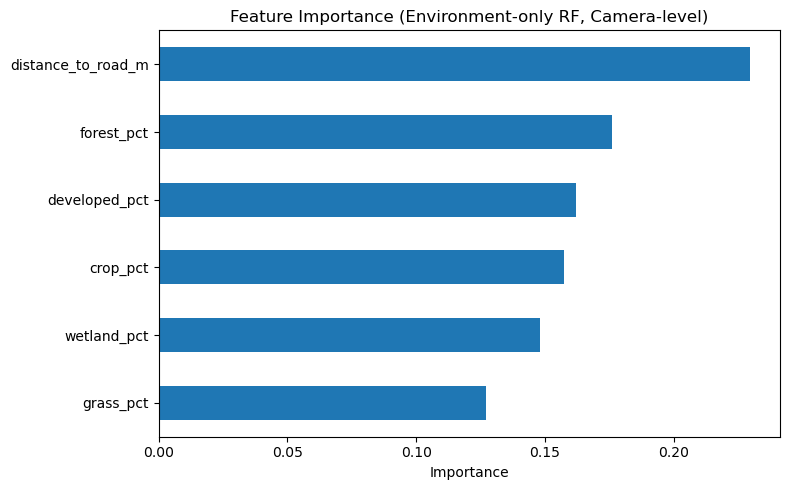

distance_to_road_m    0.229665
forest_pct            0.175770
developed_pct         0.162165
crop_pct              0.157403
wetland_pct           0.148125
grass_pct             0.126871
dtype: float64


In [43]:
importance_env = plot_feature_importance(
    rf_model_env,
    X_env.columns,
    "Feature Importance (Environment-only RF, Camera-level)"
)

# Print exact values
print(importance_env)

### Combined RF model

In [45]:
# Define predictor groups for the combined model
# -------------------------------------------------------------------
# Combined model includes:
# 1. SSUSA variable(s)
# 2. environmental variables
# 3. categorical SSUSA metadata fields
# -------------------------------------------------------------------

# Numeric SSUSA predictor
#ssusa_features = ["unique_nights"]

# Categorical SSUSA predictors
# Removing Feature type as very few cameras have feature type value 
categorical_cols = [
    "Habitat",
    "Development_Level"
]

# -------------------------------------------------------------------
# Keep only columns needed for the combined model
# -------------------------------------------------------------------
# combined_features = ssusa_features + env_features + categorical_cols + ["jaccard_index"]
combined_features =  env_features + categorical_cols + ["jaccard_index"]

# -------------------------------------------------------------------
# Remove rows missing numeric environment / response values
# -------------------------------------------------------------------
# At this stage we require:
# - unique_nights
# - all environment predictors
# - jaccard_index
#
# We are not yet dropping rows for categorical columns, because some may
# still be handled during encoding depending on their content.
# -------------------------------------------------------------------
rf_combined = rf_df.dropna(
    subset= env_features + ["jaccard_index"]
).copy()

rf_combined = rf_combined[combined_features].copy()

print("Rows before categorical processing:", rf_combined.shape[0])
print("Columns used in combined model:", rf_combined.columns.tolist())

Rows before categorical processing: 7263
Columns used in combined model: ['forest_pct', 'grass_pct', 'wetland_pct', 'developed_pct', 'crop_pct', 'distance_to_road_m', 'Habitat', 'Development_Level', 'jaccard_index']


In [46]:
# Clean categorical columns before one-hot encoding
# -------------------------------------------------------------------
# In some datasets, categorical fields like Habitat or Feature_Type
# may appear as sets rather than plain strings.
#
# Example:
#   {"forest", "wetland"}
#
# pd.get_dummies expects string-like values, so if a value is a set,
# we convert it into a single comma-separated string.
#
# Example:
#   {"forest", "wetland"}  -->  "forest,wetland"
#
# sorted(x) makes the order consistent.
# -------------------------------------------------------------------
for col in categorical_cols:
    rf_combined[col] = rf_combined[col].apply(
        lambda x: ",".join(sorted(x)) if isinstance(x, set) else x
    )

# -------------------------------------------------------------------
# One-hot encode categorical predictors
# -------------------------------------------------------------------
# This converts each category into binary dummy columns.
#
# Example:
# Habitat = "forest" becomes:
#   Habitat_forest = 1
#   Habitat_grassland = 0
#   Habitat_wetland = 0
#
# drop_first=True removes one reference level from each categorical variable
# to reduce redundancy.
#
# Since RF is tree-based, keeping all dummies is also possible,
# but drop_first=True slightly reduces the number of columns.
# -------------------------------------------------------------------
rf_combined_encoded = pd.get_dummies(
    rf_combined,
    columns=categorical_cols,
    drop_first=True
)

print("Encoded combined table shape:", rf_combined_encoded.shape)
print(rf_combined_encoded.columns.tolist())

Encoded combined table shape: (7263, 17)
['forest_pct', 'grass_pct', 'wetland_pct', 'developed_pct', 'crop_pct', 'distance_to_road_m', 'jaccard_index', 'Habitat_Beach', 'Habitat_Chaparral', 'Habitat_Desert', 'Habitat_Forest', 'Habitat_Grassland', 'Habitat_Shrubland', 'Habitat_Wetland', 'Development_Level_Suburban', 'Development_Level_Urban', 'Development_Level_Wild']


In [47]:
# Separate predictors and response for combined model
# -------------------------------------------------------------------
X_comb = rf_combined_encoded.drop(columns=["jaccard_index"])
y_comb = rf_combined_encoded["jaccard_index"]

print("Combined predictor matrix shape:", X_comb.shape)
print("Combined response vector shape:", y_comb.shape)

# -------------------------------------------------------------------
# Train/test split + fit the combined RF model
# -------------------------------------------------------------------
(
    rf_model_combined,
    X_train_comb,
    X_test_comb,
    y_train_comb,
    y_test_comb,
    y_pred_comb,
    r2_comb,
    rmse_comb,
) = fit_and_evaluate_rf(X_comb, y_comb)

# -------------------------------------------------------------------
# Print combined model performance
# -------------------------------------------------------------------
print("Combined RF")
print("R²:", round(r2_comb, 3))
print("RMSE:", round(rmse_comb, 3))

Combined predictor matrix shape: (7263, 16)
Combined response vector shape: (7263,)
Combined RF
R²: 0.272
RMSE: 0.046


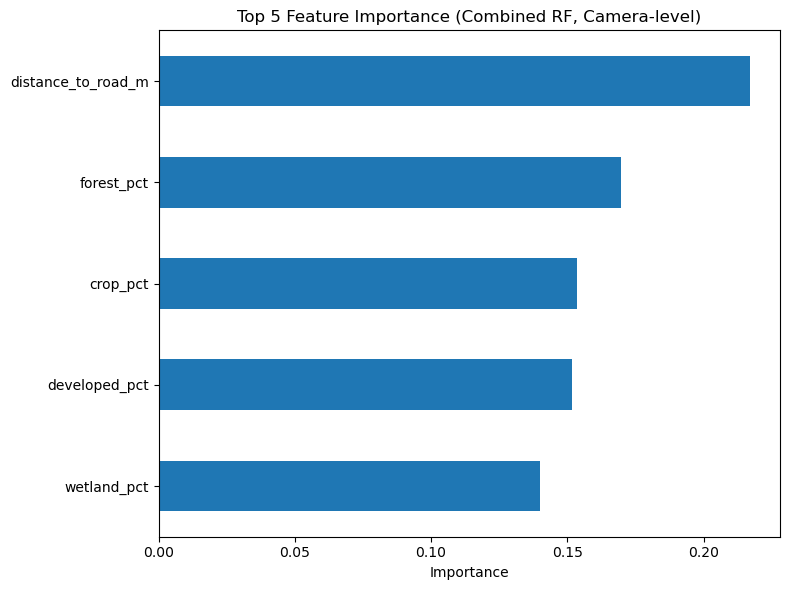

distance_to_road_m    0.217159
forest_pct            0.169770
crop_pct              0.153582
developed_pct         0.151742
wetland_pct           0.139818
dtype: float64


In [52]:
# Plot top feature importances for the combined model
# -------------------------------------------------------------------
# This shows which variables were most useful when both:
# - SSUSA variables
# - geospatial environment variables
# are included together.
#
# top_n=15 limits the plot to the 15 most important predictors,
# which makes the figure easier to read when many dummy columns exist.
# -------------------------------------------------------------------
importance_comb = plot_feature_importance(
    rf_model_combined,
    X_comb.columns,
    "Top 5 Feature Importance (Combined RF, Camera-level)",
    top_n=5,
)

# Print exact importance values for top variables
print(importance_comb.head(15))

In [134]:
results_df = pd.DataFrame({
    "Model": ["Environment-only RF", "Combined RF"],
    "R2": [r2_env, r2_comb],
    "RMSE": [rmse_env, rmse_comb]
})

results_df

,Model,R2,RMSE
0,Environment-only RF,0.306641,0.105377
1,Combined RF,0.427307,0.095769


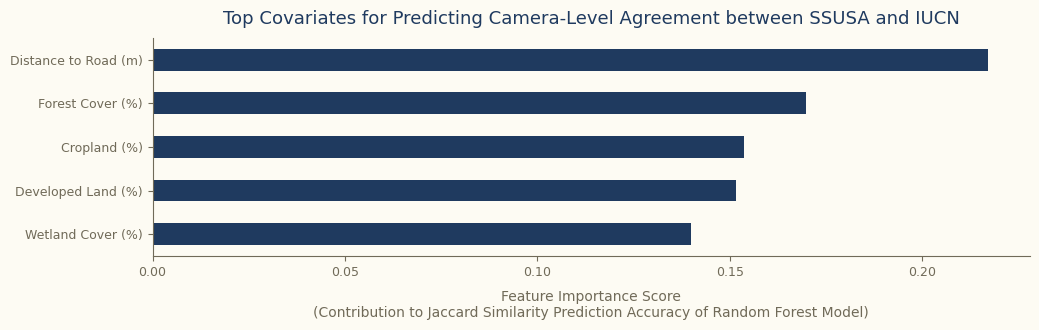

Distance to Road (m)    0.217159
Forest Cover (%)        0.169770
Cropland (%)            0.153582
Developed Land (%)      0.151742
Wetland Cover (%)       0.139818
dtype: float64


In [79]:
importance_comb = plot_feature_importance(
    rf_model_combined,
    X_comb.columns,
    "Top Covariates for Predicting Camera-Level Agreement between SSUSA and IUCN",
    top_n=5
)

print(importance_comb.head(5))